In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, cohen_kappa_score
)
import string
import re



In [2]:
# Output directory
op_dir = "OUTPUT"
os.makedirs(op_dir, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(os.path.join(op_dir, name), bbox_inches='tight')



In [3]:
#1 Loading fake and true dataset

fake = pd.read_csv(r"DATASET 1\Fake.csv",dtype=str)
true = pd.read_csv(r"DATASET 1\True.csv")

fake["label"] = 1
true["label"] = 0

df = pd.concat([fake, true], axis=0).sample(frac=1, random_state=2025)
df.reset_index(drop=True, inplace=True)

print("Dataset loaded:")
print(df["label"].value_counts())



Dataset loaded:
label
0    12030
1    11901
Name: count, dtype: int64


In [4]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [5]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [6]:
#2 Text cleaning function
def clean_text(text):
    if pd.isna(text):     # To detect missing values
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)



In [7]:
#3 Train-Test split

x_train, x_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2,stratify=df["label"]
)



In [8]:
#4 Term Frequency- Inverse Document frequency(TF-IDF) Vectorizers

tfidf = TfidfVectorizer(max_features=20000, stop_words="english")
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

feature_names = np.array(tfidf.get_feature_names_out())



In [11]:
#5 Modelling
# Model 1 — Naive Bayes

nb = MultinomialNB()
nb.fit(x_train_tfidf, y_train)





,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
# Model 2 — KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_tfidf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
#6 Evaluation

def evaluate(model, x_test, y_test, model_name):
    #print("\n" + "="*50)
    print(f"{model_name} Performance")
   # print("="*50)

    y_pred = model.predict(x_test)

    try:
        y_probablity = model.predict_proba(x_test)[:,1]
    except:
        y_probablity = None

    # Print Metrics
    print(classification_report(y_test, y_pred, digits=4))

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = recall_score(y_test, y_pred, pos_label=0)
    auc = roc_auc_score(y_test, y_probablity) if y_probablity is not None else None

    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {prec:.4f}")
    print(f"Recall        : {rec:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"Cohen's Kappa : {kappa:.4f}")
    print(f"Sensitivity   : {sensitivity:.4f}")
    print(f"Specificity   : {specificity:.4f}")
    if auc:
        print(f"AUC-ROC : {auc:.4f}")

    # Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.show()
    save_fig(fig, f"{model_name}_confusion.png")

    # ROC Curve
    if y_probablity is not None:
        fpr, tpr, _ = roc_curve(y_test, y_probablity)
        fig, ax = plt.subplots(figsize=(6,5))
        ax.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        ax.plot([0,1], [0,1], "--")
        ax.set_title(f"{model_name} - ROC Curve")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()
        plt.show()
        save_fig(fig, f"{model_name}_roc.png")

    return y_pred, y_probablity


NaiveBayes Performance
              precision    recall  f1-score   support

           0     0.9066    0.9443    0.9251      2406
           1     0.9413    0.9017    0.9211      2381

    accuracy                         0.9231      4787
   macro avg     0.9239    0.9230    0.9231      4787
weighted avg     0.9238    0.9231    0.9231      4787

Accuracy      : 0.9231
Precision     : 0.9413
Recall        : 0.9017
F1 Score      : 0.9211
Cohen's Kappa : 0.8462
Sensitivity   : 0.9017
Specificity   : 0.9443
AUC-ROC : 0.9814


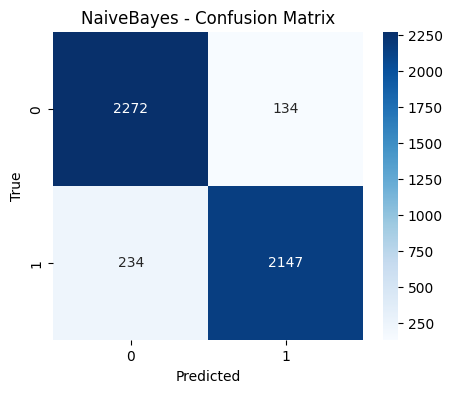

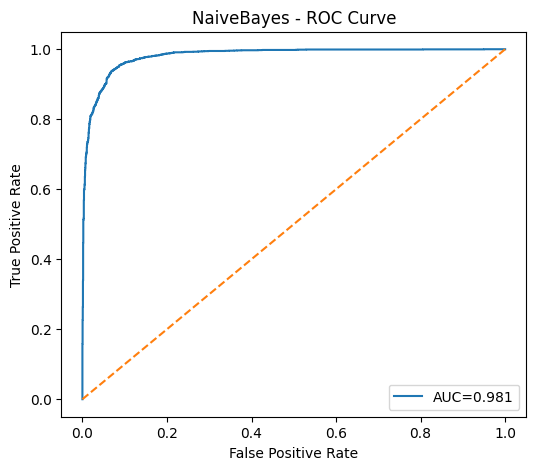

KNN Performance
              precision    recall  f1-score   support

           0     0.9165    0.2236    0.3595      2406
           1     0.5552    0.9794    0.7087      2381

    accuracy                         0.5995      4787
   macro avg     0.7359    0.6015    0.5341      4787
weighted avg     0.7368    0.5995    0.5332      4787

Accuracy      : 0.5995
Precision     : 0.5552
Recall        : 0.9794
F1 Score      : 0.7087
Cohen's Kappa : 0.2022
Sensitivity   : 0.9794
Specificity   : 0.2236
AUC-ROC : 0.7025


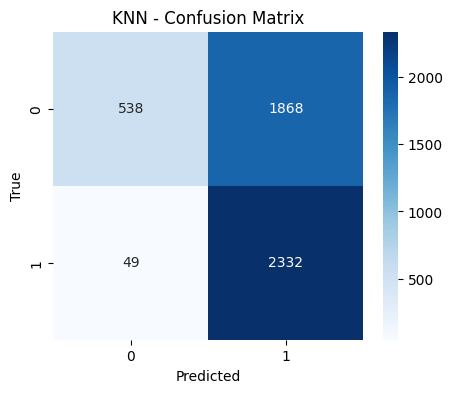

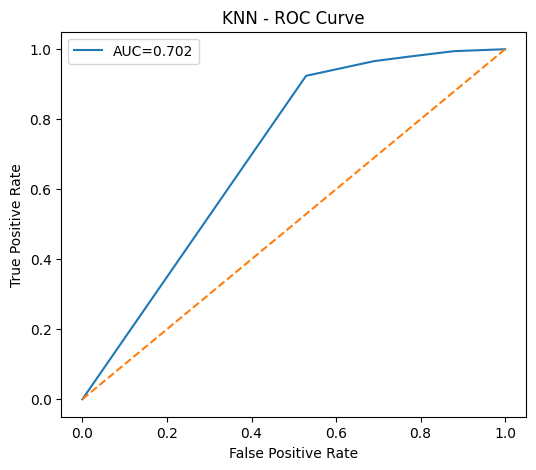

In [14]:
#7 Running both models simultaneously

nb_pred, nb_proba = evaluate(nb, x_test_tfidf, y_test, "NaiveBayes")
knn_pred, knn_proba = evaluate(knn, x_test_tfidf, y_test, "KNN")


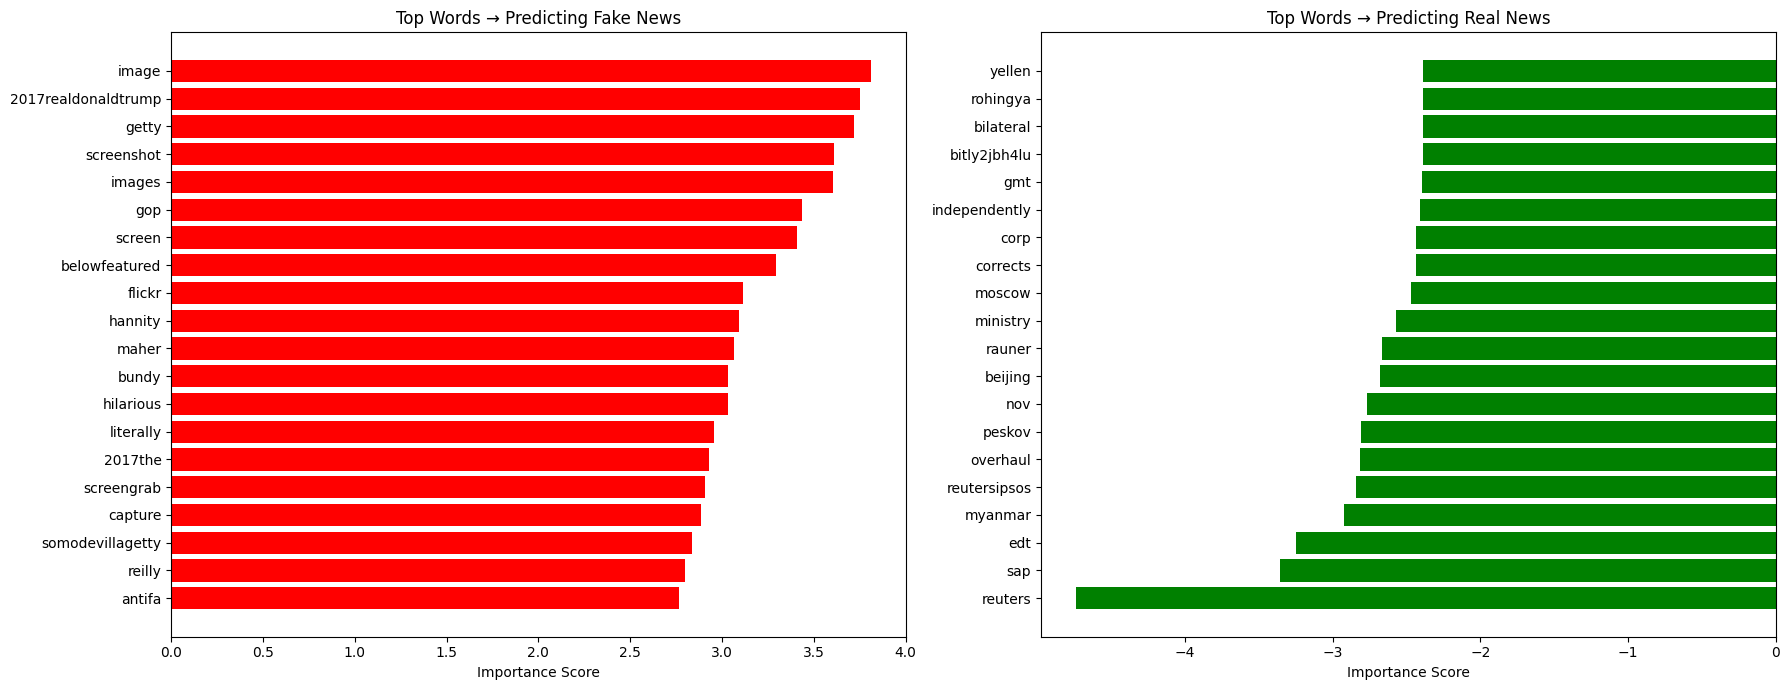

In [26]:
# 8) NB Feature 

# Getting log probabilities for each class
fake_log_prob = nb.feature_log_prob_[1]   # Class 1 = Fake
real_log_prob = nb.feature_log_prob_[0]   # Class 0 = Real

# Feature importance 
nb_importance = fake_log_prob - real_log_prob

# Top 20 fake-indicating words
top_fake_idx = np.argsort(nb_importance)[-20:]

# Top 20 real-indicating words
top_real_idx = np.argsort(nb_importance)[:20]

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

ax[0].barh(feature_names[top_fake_idx], nb_importance[top_fake_idx], color="red")
ax[0].set_title("Top Words → Predicting Fake News")
ax[0].set_xlabel("Importance Score")

ax[1].barh(feature_names[top_real_idx], nb_importance[top_real_idx], color="green")
ax[1].set_title("Top Words → Predicting Real News")
ax[1].set_xlabel("Importance Score")

save_fig(fig, "NaiveBayes_top_words.png")

plt.tight_layout()
plt.show()




In [27]:
# Naive Bayes (Fake vs Real)


from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Getting log probabilities for each class
fake_log_prob = nb.feature_log_prob_[1]   # Class 1 = Fake
real_log_prob = nb.feature_log_prob_[0]   # Class 0 = Real

# Featuring importance 
nb_importance = fake_log_prob - real_log_prob

# Top 50 words overall by absolute importance
top_idx = np.argsort(np.abs(nb_importance))[-50:]
top_features = np.array(feature_names)[top_idx]
top_scores = nb_importance[top_idx]



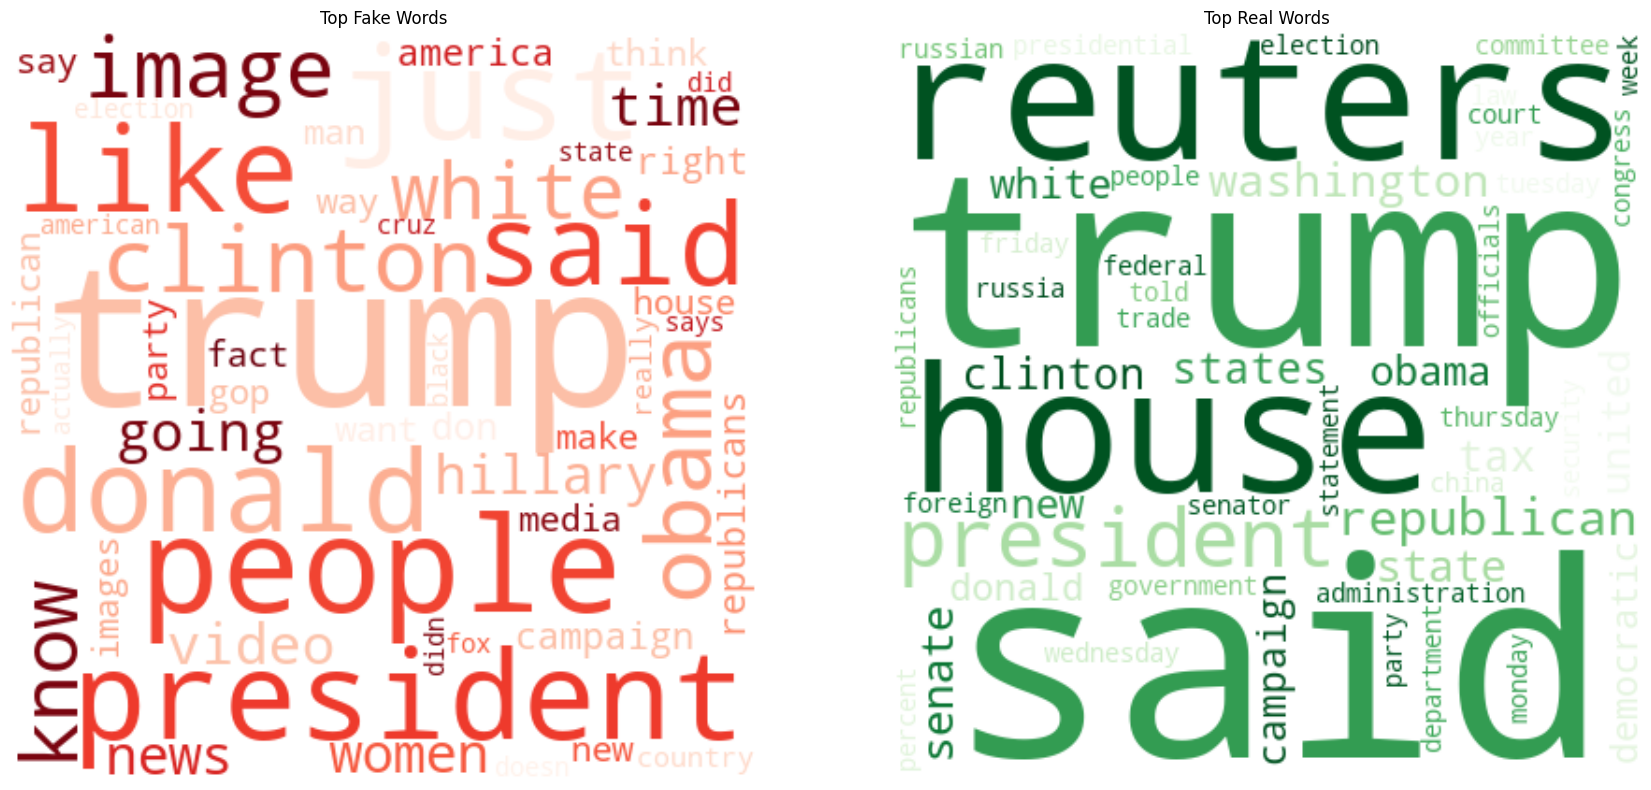

In [28]:
# 1) Word Clouds
fake_dict = {feature_names[i]: np.exp(fake_log_prob[i]) for i in np.argsort(fake_log_prob)[-50:]}
real_dict = {feature_names[i]: np.exp(real_log_prob[i]) for i in np.argsort(real_log_prob)[-50:]}

fig, axes = plt.subplots(1, 2, figsize=(18,8))
wc_fake = WordCloud(width=400, height=400, background_color='white', colormap='Reds').generate_from_frequencies(fake_dict)
wc_real = WordCloud(width=400, height=400, background_color='white', colormap='Greens').generate_from_frequencies(real_dict)

axes[0].imshow(wc_fake, interpolation='bilinear'); axes[0].axis('off'); axes[0].set_title("Top Fake Words")
axes[1].imshow(wc_real, interpolation='bilinear'); axes[1].axis('off'); axes[1].set_title("Top Real Words")

save_fig(plt.gcf(), "NaiveBayes_wordcloud_fake_real.png")

plt.tight_layout()
plt.show()

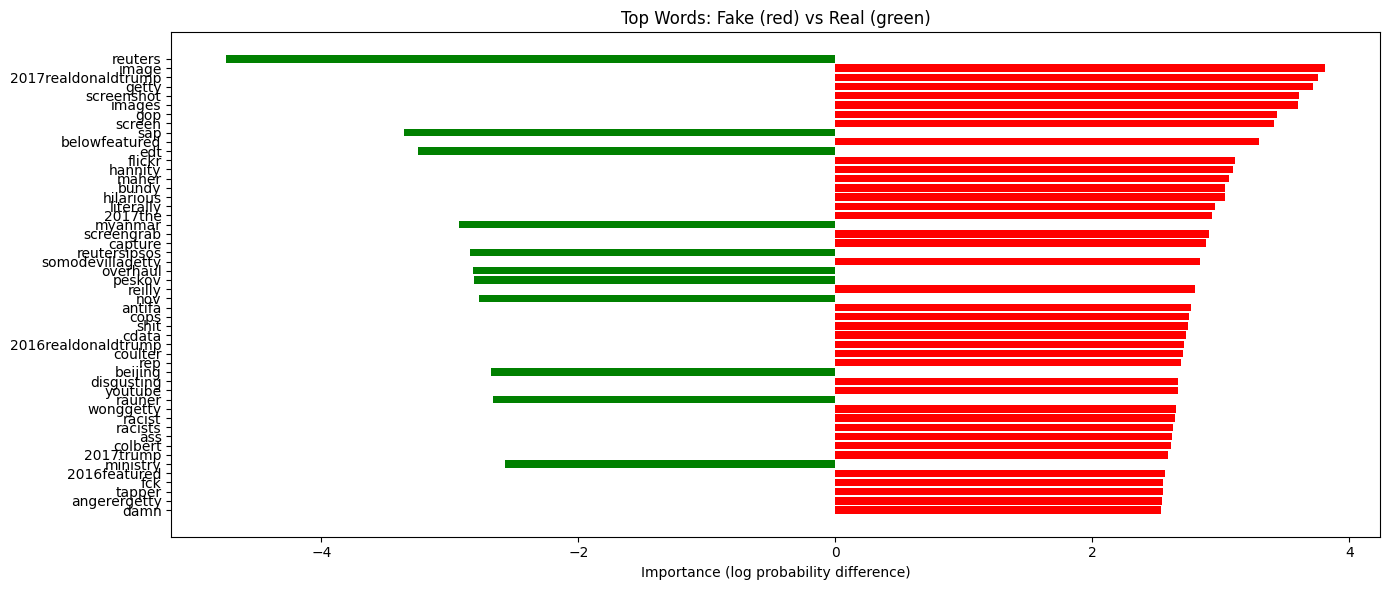

In [29]:
#2) Polarity Bar plot (Fake vs real)
fig, ax = plt.subplots(figsize=(14,6))
colors = ['red' if x>0 else 'green' for x in top_scores]
ax.barh(top_features, top_scores, color=colors)
ax.set_xlabel("Importance (log probability difference)")
ax.set_title("Top Words: Fake (red) vs Real (green)")
save_fig(plt.gcf(), "NaiveBayes_top_words_polarity.png")
plt.tight_layout()
plt.show()


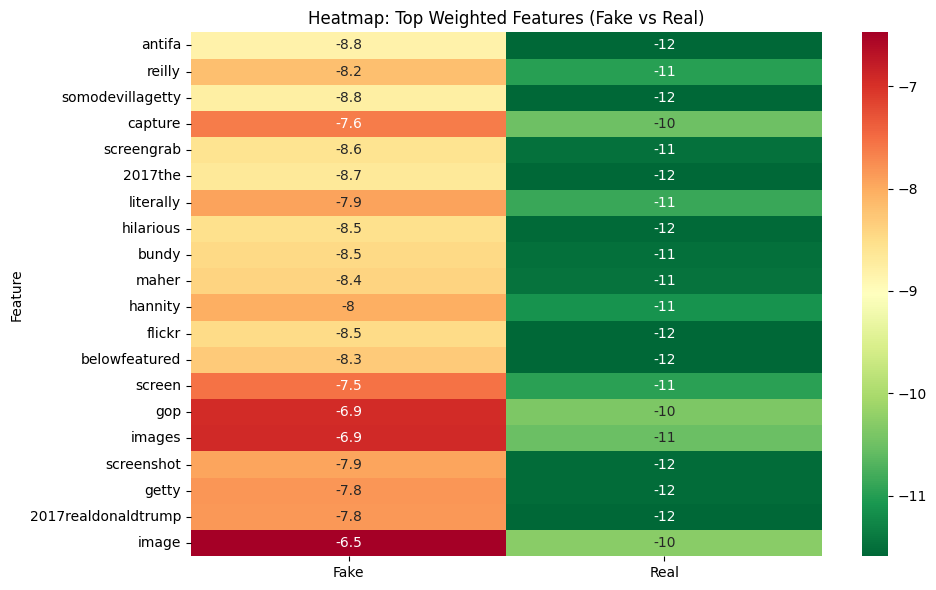

In [30]:
# 3) Heatmap of top weighted features
top_heat_idx = np.argsort(nb_importance)[-20:]  
heat_data = pd.DataFrame({
    'Feature': np.array(feature_names)[top_heat_idx],
    'Fake': fake_log_prob[top_heat_idx],
    'Real': real_log_prob[top_heat_idx]
}).set_index('Feature')

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(heat_data, annot=True, cmap='RdYlGn_r', ax=ax)
ax.set_title("Heatmap: Top Weighted Features (Fake vs Real)")
save_fig(plt.gcf(), "NaiveBayes_top_features_heatmap.png")
plt.tight_layout()
plt.show()
